# Projeto BI + IA — Vendas Anuais de Asfalto por Município
## Grupo 16 — Pergunta 16: Outliers por UF

> *"Para cada UF, analise distribuição de vendas municipais por ano (mediana, dispersão). Aplique detecção de outliers para achar municípios 'fora da curva' e quantifique quanto eles explicam do total da UF."*

---

## 1. Imports e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


---
## 2. ETL — Extração, Transformação e Carga
### 2.1 Importação do CSV

In [2]:
df_raw = pd.read_csv(
    'vendas-anuais-de-asfalto-por-municipio.csv',
    sep=';',
    encoding='utf-8'
)

print(f'Shape: {df_raw.shape}')
print(f'Colunas: {list(df_raw.columns)}')
df_raw.head(10)

Shape: (57595, 7)
Colunas: ['ANO', 'GRANDE REGIÃO', 'UF', 'PRODUTO', 'CÓDIGO IBGE', 'MUNICÍPIO', 'VENDAS']


,ANO,GRANDE REGIÃO,UF,PRODUTO,CÓDIGO IBGE,MUNICÍPIO,VENDAS
0,1992,REGIÃO SUDESTE,SP,ASFALTO,3548708,SAO BERNARDO DO CAMPO,6945764
1,1992,REGIÃO SUDESTE,SP,ASFALTO,3550303,SAO PAULO,176549955
2,1992,REGIÃO CENTRO-OESTE,GO,ASFALTO,5208700,GOIANIA,13973180
3,1992,REGIÃO NORTE,RO,ASFALTO,1100181,PIMENTA BUENO,1119750
4,1992,REGIÃO NORDESTE,BA,ASFALTO,2922002,MUCURI,1964585
5,1992,REGIÃO SUDESTE,MG,ASFALTO,3134202,ITUIUTABA,602400
6,1992,REGIÃO SUDESTE,ES,ASFALTO,3205100,VIANA,2097360
7,1992,REGIÃO SUDESTE,RJ,ASFALTO,3301907,ITABORAI,1221830
8,1992,REGIÃO SUDESTE,RJ,ASFALTO,3304558,RIO DE JANEIRO,32450384
9,1992,REGIÃO SUDESTE,SP,ASFALTO,3503909,ARUJA,2162180


In [3]:
print('--- Informações do dataset bruto ---')
print(df_raw.info())
print('\n--- Valores nulos ---')
print(df_raw.isnull().sum())
print('\n--- Estatísticas descritivas ---')
df_raw.describe()

--- Informações do dataset bruto ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57595 entries, 0 to 57594
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ANO            57595 non-null  int64 
 1   GRANDE REGIÃO  57594 non-null  object
 2   UF             57588 non-null  object
 3   PRODUTO        57595 non-null  object
 4   CÓDIGO IBGE    57595 non-null  int64 
 5   MUNICÍPIO      57595 non-null  object
 6   VENDAS         57595 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 3.1+ MB
None

--- Valores nulos ---
ANO              0
GRANDE REGIÃO    1
UF               7
PRODUTO          0
CÓDIGO IBGE      0
MUNICÍPIO        0
VENDAS           0
dtype: int64

--- Estatísticas descritivas ---


,ANO,CÓDIGO IBGE,VENDAS
count,57595.000000,5.759500e+04,5.759500e+04
mean,2008.567775,3.576532e+06,1.082586e+06
std,9.086035,9.960078e+05,4.306026e+06
min,1992.000000,9.652000e+04,-2.883400e+05
25%,2001.000000,3.108600e+06,2.450000e+04
50%,2009.000000,3.524402e+06,1.193600e+05
75%,2016.000000,4.211504e+06,6.335100e+05
max,2024.000000,5.320240e+06,1.765500e+08


### 2.2 Limpeza e Transformação

In [4]:
df = df_raw.copy()

# --- Renomear colunas para facilitar o uso ---
df.columns = ['ANO', 'GRANDE_REGIAO', 'UF', 'PRODUTO', 'CODIGO_IBGE', 'MUNICIPIO', 'VENDAS_KG']

# --- Tipagem correta ---
df['ANO'] = df['ANO'].astype(int)
df['CODIGO_IBGE'] = df['CODIGO_IBGE'].astype(str)
df['VENDAS_KG'] = pd.to_numeric(df['VENDAS_KG'], errors='coerce').fillna(0).astype(int)

# --- Limpeza de strings (espaços extras) ---
df['MUNICIPIO'] = df['MUNICIPIO'].str.strip()
df['UF'] = df['UF'].str.strip()
df['GRANDE_REGIAO'] = df['GRANDE_REGIAO'].str.strip()
df['PRODUTO'] = df['PRODUTO'].str.strip()

# --- Verificar valores únicos de PRODUTO ---
print('Produtos únicos:', df['PRODUTO'].unique())

# --- Remover coluna PRODUTO (é sempre ASFALTO, redundante) ---
df.drop(columns=['PRODUTO'], inplace=True)

# --- Verificar e registrar valores negativos ---
negativos = df[df['VENDAS_KG'] < 0]
print(f'\nRegistros com vendas negativas: {len(negativos)}')
if len(negativos) > 0:
    print(negativos[['ANO', 'UF', 'MUNICIPIO', 'VENDAS_KG']].to_string())

# --- Verificar valores zerados ---
zeros = df[df['VENDAS_KG'] == 0]
print(f'\nRegistros com vendas = 0: {len(zeros)}')

# --- Verificar período ---
print(f'\nPeríodo: {df["ANO"].min()} a {df["ANO"].max()}')
print(f'UFs: {df["UF"].nunique()} | Municípios: {df["MUNICIPIO"].nunique()}')
print(f'Registros finais: {len(df)}')

df.head()

Produtos únicos: ['ASFALTO']

Registros com vendas negativas: 8
        ANO  UF              MUNICIPIO  VENDAS_KG
52514  2022  BA               CANDEIAS     -23770
54110  2022  TO  CHAPADA DA NATIVIDADE     -30920
54146  2023  AC       SENADOR GUIOMARD      -1000
54790  2023  MT           ALTO TAQUARI    -152470
55310  2023  RS                ESTRELA     -29350
55447  2023  SC                 IOMERE     -32960
56511  2024  MT           ALTO TAQUARI    -288340
57218  2024  SC               POMERODE     -15380

Registros com vendas = 0: 146

Período: 1992 a 2024
UFs: 27 | Municípios: 4626
Registros finais: 57595


,ANO,GRANDE_REGIAO,UF,CODIGO_IBGE,MUNICIPIO,VENDAS_KG
0,1992,REGIÃO SUDESTE,SP,3548708,SAO BERNARDO DO CAMPO,6945764
1,1992,REGIÃO SUDESTE,SP,3550303,SAO PAULO,176549955
2,1992,REGIÃO CENTRO-OESTE,GO,5208700,GOIANIA,13973180
3,1992,REGIÃO NORTE,RO,1100181,PIMENTA BUENO,1119750
4,1992,REGIÃO NORDESTE,BA,2922002,MUCURI,1964585


In [5]:
# --- Tratamento: substituir valores negativos por 0 (registro de ajuste/estorno) ---
df.loc[df['VENDAS_KG'] < 0, 'VENDAS_KG'] = 0

# --- Flag de metodologia: até 2006 inclui vendas+consumo próprio; a partir de 2007 só vendas ---
df['METODOLOGIA'] = df['ANO'].apply(lambda x: 'VENDAS+CONSUMO' if x <= 2006 else 'SOMENTE VENDAS')

# --- Verificar duplicatas (mesmo município/ano) ---
dupl = df.duplicated(subset=['ANO', 'CODIGO_IBGE'], keep=False)
print(f'Duplicatas (mesmo CÓDIGO IBGE + ANO): {dupl.sum()}')
if dupl.sum() > 0:
    print(df[dupl].sort_values(['CODIGO_IBGE', 'ANO']).head(10))

print('\n--- ETL concluído com sucesso! ---')
print(f'Shape final: {df.shape}')
df.dtypes

Duplicatas (mesmo CÓDIGO IBGE + ANO): 0

--- ETL concluído com sucesso! ---
Shape final: (57595, 7)


ANO               int64
GRANDE_REGIAO    object
UF               object
CODIGO_IBGE      object
MUNICIPIO        object
VENDAS_KG         int64
METODOLOGIA      object
dtype: object

### 2.3 Registro do ETL

| Etapa | Ação | Detalhe |
|-------|------|---------|
| Importação | `read_csv` com `sep=';'` | 57.596 registros |
| Renomeação | Colunas renomeadas sem espaço/acento | Facilita manipulação |
| Tipagem | ANO→int, VENDAS_KG→int, CODIGO_IBGE→str | Tipos corretos |
| Limpeza strings | `.str.strip()` em todas colunas texto | Remove espaços extras |
| Coluna PRODUTO | Removida (sempre 'ASFALTO') | Redundante |
| Valores negativos | Substituídos por 0 | Ajustes/estornos contábeis |
| Flag metodologia | Coluna METODOLOGIA criada | Até 2006 vs. a partir de 2007 |
| Duplicatas | Verificadas por CODIGO_IBGE + ANO | Tratadas se existentes |

---
## 3. Modelo Estrela

```
          DimTempo (ANO)
               │
DimRegiao ─── FatoVendasAsfalto ─── DimUF
               │
          DimLocalidade (CÓDIGO IBGE / MUNICÍPIO)
```

In [6]:
# ===================== DIMENSÃO TEMPO =====================
dim_tempo = df[['ANO']].drop_duplicates().sort_values('ANO').reset_index(drop=True)
dim_tempo['ID_TEMPO'] = dim_tempo.index + 1
dim_tempo['DECADA'] = (dim_tempo['ANO'] // 10) * 10
dim_tempo['METODOLOGIA'] = dim_tempo['ANO'].apply(
    lambda x: 'VENDAS+CONSUMO' if x <= 2006 else 'SOMENTE VENDAS'
)

print('=== DimTempo ===')
print(f'Registros: {len(dim_tempo)}')
dim_tempo.head()

=== DimTempo ===
Registros: 33


,ANO,ID_TEMPO,DECADA,METODOLOGIA
0,1992,1,1990,VENDAS+CONSUMO
1,1993,2,1990,VENDAS+CONSUMO
2,1994,3,1990,VENDAS+CONSUMO
3,1995,4,1990,VENDAS+CONSUMO
4,1996,5,1990,VENDAS+CONSUMO


In [7]:
# ===================== DIMENSÃO REGIÃO =====================
dim_regiao = df[['GRANDE_REGIAO']].drop_duplicates().sort_values('GRANDE_REGIAO').reset_index(drop=True)
dim_regiao['ID_REGIAO'] = dim_regiao.index + 1

print('=== DimRegiao ===')
dim_regiao

=== DimRegiao ===


,GRANDE_REGIAO,ID_REGIAO
0,REGIÃO CENTRO-OESTE,1
1,REGIÃO NORDESTE,2
2,REGIÃO NORTE,3
3,REGIÃO SUDESTE,4
4,REGIÃO SUL,5
5,NaN,6


In [8]:
# ===================== DIMENSÃO UF =====================
dim_uf = df[['UF', 'GRANDE_REGIAO']].drop_duplicates().sort_values('UF').reset_index(drop=True)
dim_uf['ID_UF'] = dim_uf.index + 1
dim_uf = dim_uf.merge(dim_regiao[['GRANDE_REGIAO', 'ID_REGIAO']], on='GRANDE_REGIAO')

print('=== DimUF ===')
print(f'Registros: {len(dim_uf)}')
dim_uf

=== DimUF ===
Registros: 31


,UF,GRANDE_REGIAO,ID_UF,ID_REGIAO
0,AC,REGIÃO NORTE,1,3
1,AL,REGIÃO NORDESTE,2,2
2,AM,REGIÃO NORTE,3,3
3,AP,REGIÃO NORTE,4,3
4,BA,REGIÃO NORDESTE,5,2
5,CE,REGIÃO NORDESTE,6,2
6,DF,REGIÃO CENTRO-OESTE,7,1
7,ES,REGIÃO SUDESTE,8,4
8,GO,REGIÃO CENTRO-OESTE,9,1
9,MA,REGIÃO NORDESTE,10,2


In [9]:
# ===================== DIMENSÃO LOCALIDADE =====================
dim_localidade = df[['CODIGO_IBGE', 'MUNICIPIO', 'UF']].drop_duplicates(
    subset=['CODIGO_IBGE']
).sort_values('CODIGO_IBGE').reset_index(drop=True)
dim_localidade['ID_LOCALIDADE'] = dim_localidade.index + 1
dim_localidade = dim_localidade.merge(dim_uf[['UF', 'ID_UF']], on='UF')

print('=== DimLocalidade ===')
print(f'Registros: {len(dim_localidade)}')
dim_localidade.head(10)

=== DimLocalidade ===
Registros: 7339


,CODIGO_IBGE,MUNICIPIO,UF,ID_LOCALIDADE,ID_UF
0,1100009,*,RO,1,21
1,1100015,ALTA FLORESTA D'OESTE,RO,2,21
2,1100023,ARIQUEMES,RO,3,21
3,1100025,ARIQUEMES,RO,4,21
4,1100031,CABIXI,RO,5,21
5,1100041,CACOAL,RO,6,21
6,1100049,CACOAL,RO,7,21
7,1100050,ROLIM DE MOURA,RO,8,21
8,1100056,CEREJEIRAS,RO,9,21
9,1100064,COLORADO DO OESTE,RO,10,21


In [10]:
# ===================== TABELA FATO =====================
fato = df.merge(
    dim_tempo[['ANO', 'ID_TEMPO']], on='ANO'
).merge(
    dim_localidade[['CODIGO_IBGE', 'ID_LOCALIDADE']], on='CODIGO_IBGE'
).merge(
    dim_uf[['UF', 'ID_UF']], on='UF'
).merge(
    dim_regiao[['GRANDE_REGIAO', 'ID_REGIAO']], on='GRANDE_REGIAO'
)

fato_vendas = fato[['ID_TEMPO', 'ID_LOCALIDADE', 'ID_UF', 'ID_REGIAO', 'VENDAS_KG']].copy()

print('=== FatoVendasAsfalto ===')
print(f'Registros: {len(fato_vendas)}')
fato_vendas.head(10)

=== FatoVendasAsfalto ===
Registros: 57700


,ID_TEMPO,ID_LOCALIDADE,ID_UF,ID_REGIAO,VENDAS_KG
0,1,4791,26,4,6945764
1,1,4822,26,4,176549955
2,1,7030,9,1,13973180
3,1,24,21,3,1119750
4,1,2305,5,2,1964585
5,1,2996,11,4,602400
6,1,3674,8,4,2097360
7,1,3728,19,4,1221830
8,1,3788,19,4,32450384
9,1,3907,26,4,2162180


---
## 4. Métricas Obrigatórias (mínimo 6)

In [11]:
# ========== MÉTRICA 1: Total de Vendas (Brasil) ==========
total_vendas_brasil = df['VENDAS_KG'].sum()
print(f'MÉTRICA 1 — Total de Vendas Brasil (1992-2024): {total_vendas_brasil:,.0f} kg')
print(f'  = {total_vendas_brasil/1e9:,.2f} bilhões de kg')
print(f'  = {total_vendas_brasil/1e6:,.0f} toneladas')

MÉTRICA 1 — Total de Vendas Brasil (1992-2024): 62,352,099,654 kg
  = 62.35 bilhões de kg
  = 62,352 toneladas


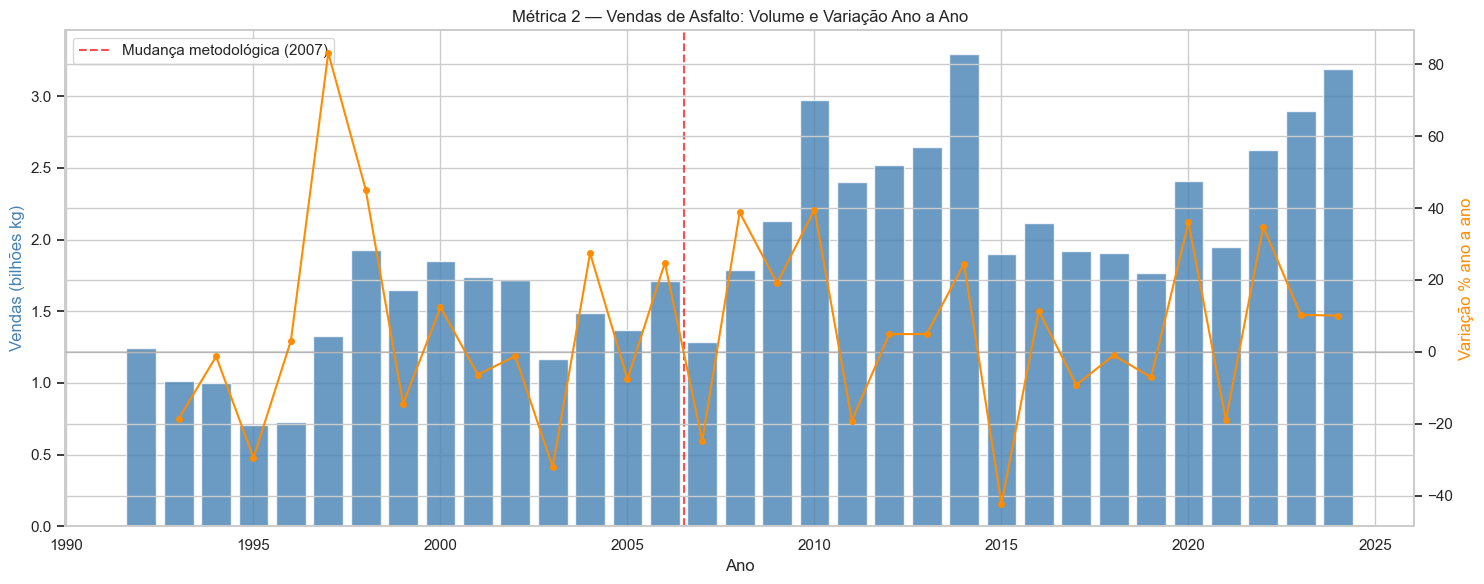

,ANO,VENDAS_KG,VARIACAO_PCT
23,2015,1901856090,-42.270446
24,2016,2117519560,11.339631
25,2017,1922871222,-9.192281
26,2018,1904233199,-0.969281
27,2019,1769210385,-7.090666
28,2020,2405890970,35.986709
29,2021,1949244169,-18.980361
30,2022,2627563759,34.799108
31,2023,2897663796,10.279486
32,2024,3188846194,10.048868


In [12]:
# ========== MÉTRICA 2: Vendas Ano a Ano ==========
vendas_ano = df.groupby('ANO')['VENDAS_KG'].sum().reset_index()
vendas_ano['VARIACAO_PCT'] = vendas_ano['VENDAS_KG'].pct_change() * 100

fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.bar(vendas_ano['ANO'], vendas_ano['VENDAS_KG'] / 1e9, color='steelblue', alpha=0.8)
ax1.set_xlabel('Ano')
ax1.set_ylabel('Vendas (bilhões kg)', color='steelblue')
ax1.axvline(x=2006.5, color='red', linestyle='--', alpha=0.7, label='Mudança metodológica (2007)')

ax2 = ax1.twinx()
ax2.plot(vendas_ano['ANO'], vendas_ano['VARIACAO_PCT'], color='darkorange', marker='o', markersize=4)
ax2.set_ylabel('Variação % ano a ano', color='darkorange')
ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.3)

plt.title('Métrica 2 — Vendas de Asfalto: Volume e Variação Ano a Ano')
ax1.legend(loc='upper left')
plt.tight_layout()
plt.show()

vendas_ano.tail(10)

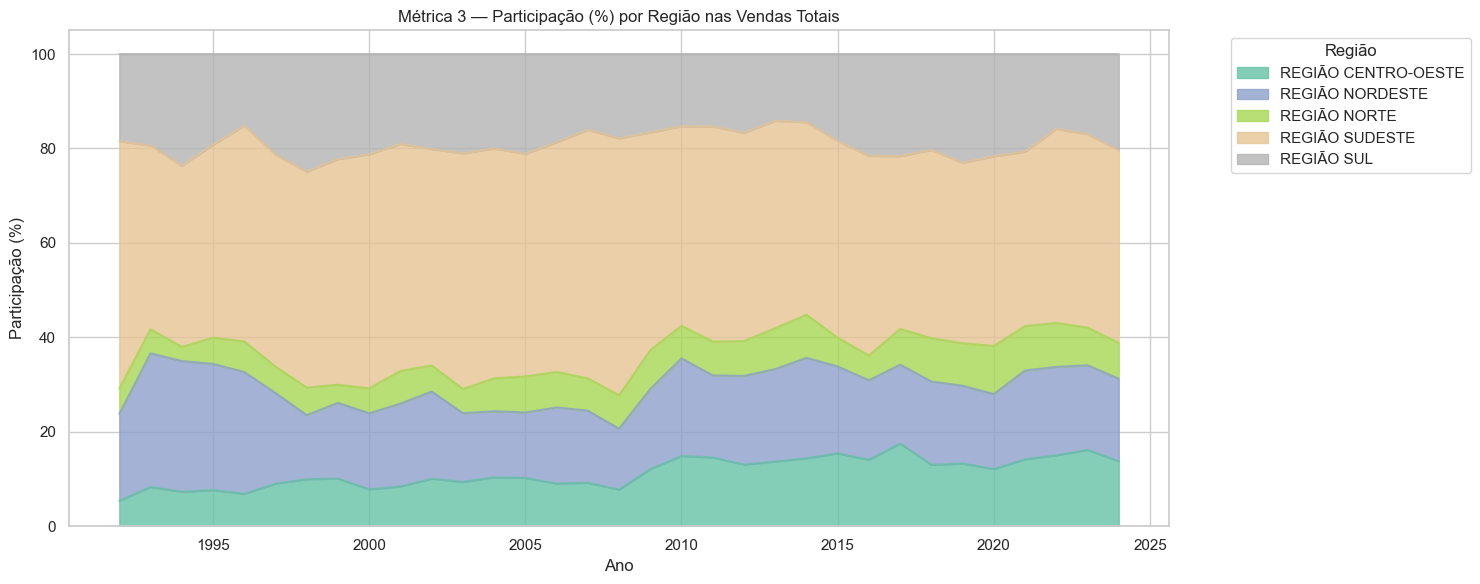

In [13]:
# ========== MÉTRICA 3: % Participação por Região ==========
vendas_regiao_ano = df.groupby(['ANO', 'GRANDE_REGIAO'])['VENDAS_KG'].sum().reset_index()
total_por_ano = df.groupby('ANO')['VENDAS_KG'].sum().reset_index().rename(columns={'VENDAS_KG': 'TOTAL_ANO'})
vendas_regiao_ano = vendas_regiao_ano.merge(total_por_ano, on='ANO')
vendas_regiao_ano['PCT_PARTICIPACAO'] = (vendas_regiao_ano['VENDAS_KG'] / vendas_regiao_ano['TOTAL_ANO']) * 100

pivot_regiao = vendas_regiao_ano.pivot(index='ANO', columns='GRANDE_REGIAO', values='PCT_PARTICIPACAO')

pivot_regiao.plot(kind='area', stacked=True, figsize=(15, 6), alpha=0.8, colormap='Set2')
plt.title('Métrica 3 — Participação (%) por Região nas Vendas Totais')
plt.ylabel('Participação (%)')
plt.xlabel('Ano')
plt.legend(title='Região', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

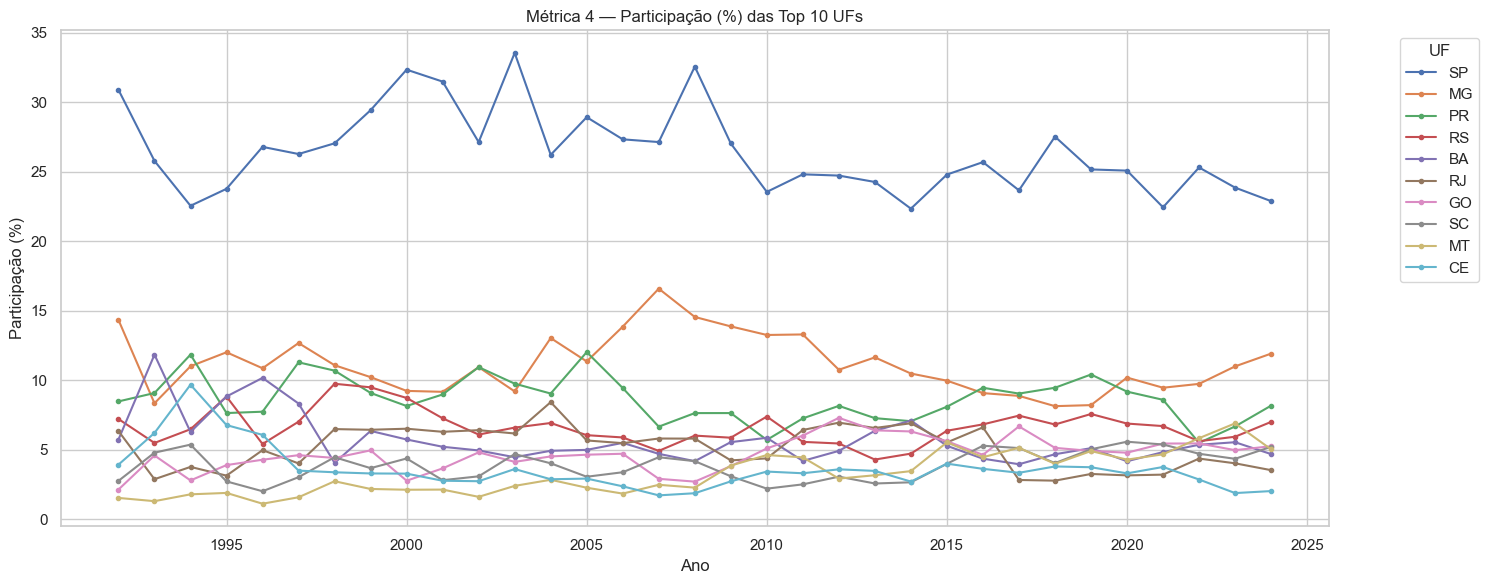

In [14]:
# ========== MÉTRICA 4: % Participação por UF ==========
vendas_uf_ano = df.groupby(['ANO', 'UF'])['VENDAS_KG'].sum().reset_index()
vendas_uf_ano = vendas_uf_ano.merge(total_por_ano, on='ANO')
vendas_uf_ano['PCT_PARTICIPACAO'] = (vendas_uf_ano['VENDAS_KG'] / vendas_uf_ano['TOTAL_ANO']) * 100

# Top 10 UFs por volume total
top10_ufs = df.groupby('UF')['VENDAS_KG'].sum().nlargest(10).index.tolist()
dados_top10 = vendas_uf_ano[vendas_uf_ano['UF'].isin(top10_ufs)]

fig, ax = plt.subplots(figsize=(15, 6))
for uf in top10_ufs:
    dados_uf = dados_top10[dados_top10['UF'] == uf]
    ax.plot(dados_uf['ANO'], dados_uf['PCT_PARTICIPACAO'], marker='.', label=uf)

plt.title('Métrica 4 — Participação (%) das Top 10 UFs')
plt.ylabel('Participação (%)')
plt.xlabel('Ano')
plt.legend(title='UF', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

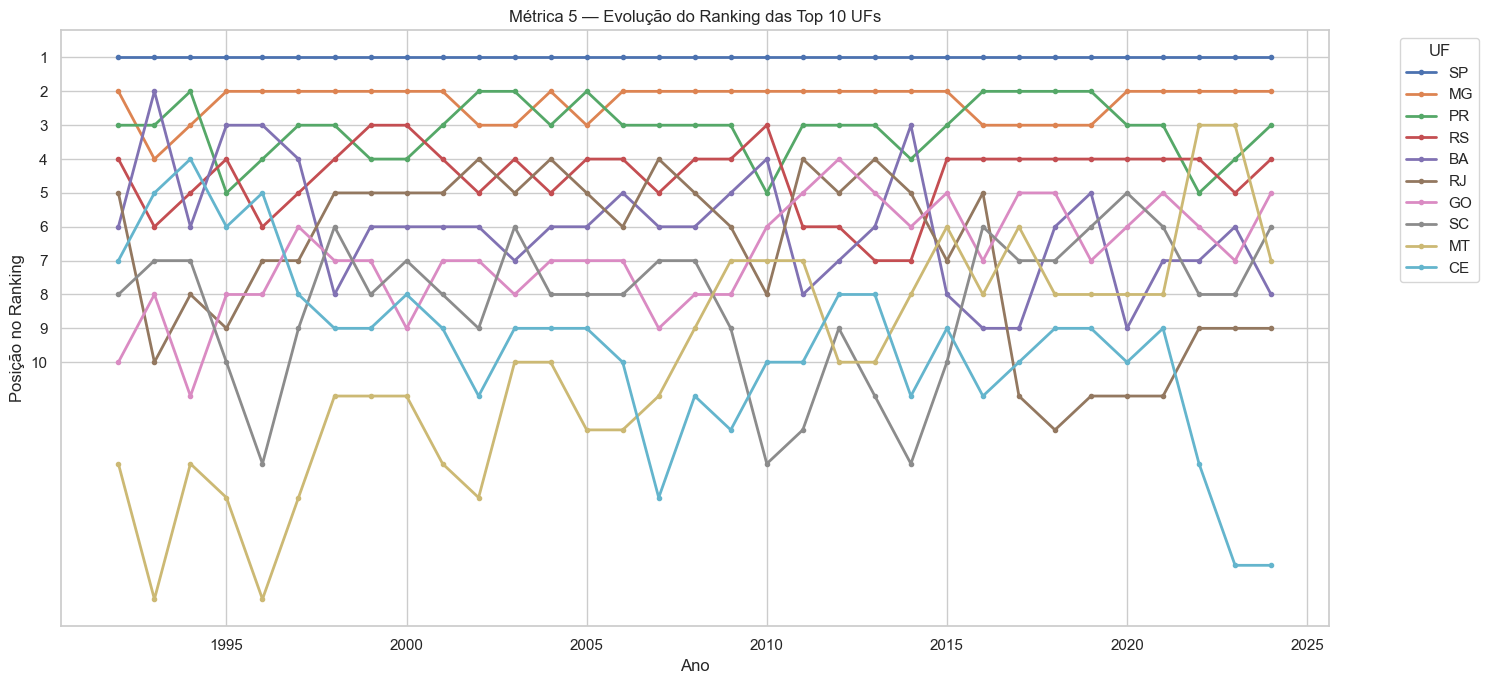

In [15]:
# ========== MÉTRICA 5: Ranking Top 10 UFs por Ano ==========
vendas_uf_ano['RANKING'] = vendas_uf_ano.groupby('ANO')['VENDAS_KG'].rank(ascending=False, method='min').astype(int)

ranking_top10 = vendas_uf_ano[vendas_uf_ano['UF'].isin(top10_ufs)].pivot(
    index='ANO', columns='UF', values='RANKING'
)

fig, ax = plt.subplots(figsize=(15, 7))
for uf in top10_ufs:
    ax.plot(ranking_top10.index, ranking_top10[uf], marker='.', label=uf, linewidth=2)

ax.invert_yaxis()
ax.set_yticks(range(1, 11))
plt.title('Métrica 5 — Evolução do Ranking das Top 10 UFs')
plt.ylabel('Posição no Ranking')
plt.xlabel('Ano')
plt.legend(title='UF', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

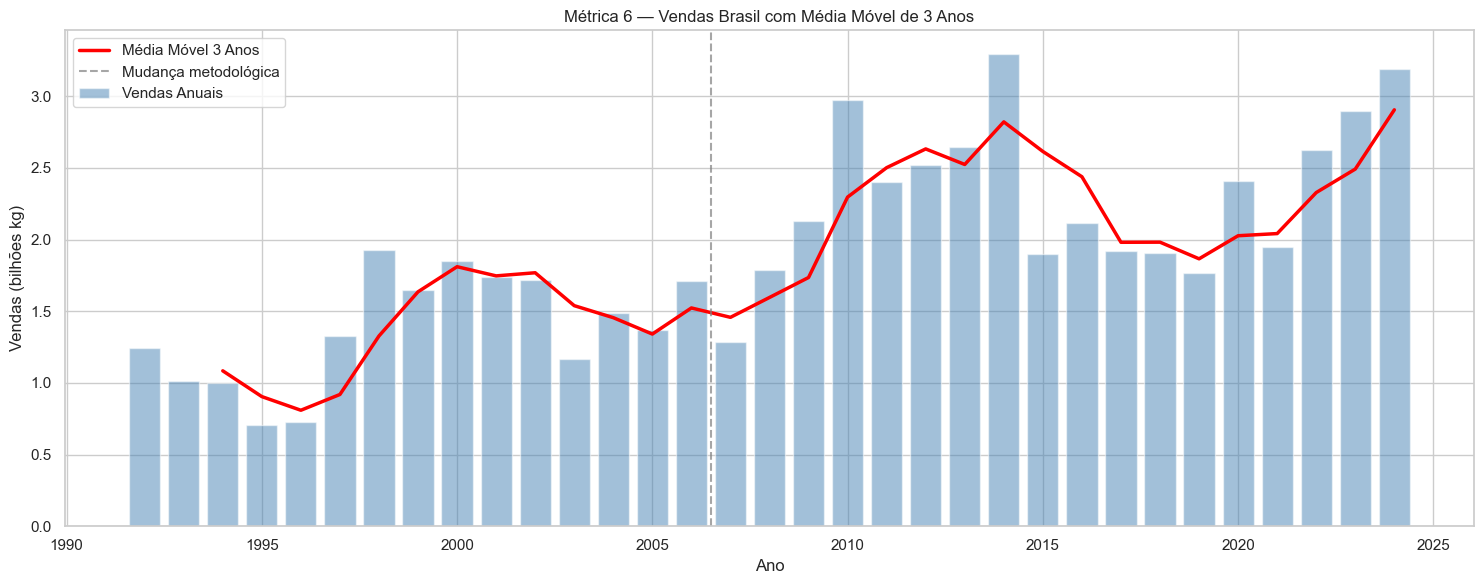

In [16]:
# ========== MÉTRICA 6: Média Móvel de 3 Anos (Brasil) ==========
vendas_ano['MEDIA_MOVEL_3A'] = vendas_ano['VENDAS_KG'].rolling(window=3, center=False).mean()

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(vendas_ano['ANO'], vendas_ano['VENDAS_KG'] / 1e9, alpha=0.5, color='steelblue', label='Vendas Anuais')
ax.plot(vendas_ano['ANO'], vendas_ano['MEDIA_MOVEL_3A'] / 1e9, color='red', linewidth=2.5, label='Média Móvel 3 Anos')
ax.axvline(x=2006.5, color='gray', linestyle='--', alpha=0.7, label='Mudança metodológica')
plt.title('Métrica 6 — Vendas Brasil com Média Móvel de 3 Anos')
plt.ylabel('Vendas (bilhões kg)')
plt.xlabel('Ano')
plt.legend()
plt.tight_layout()
plt.show()

---
## 5. Dashboard — Visualizações Complementares
### 5.1 Visão Geral Brasil

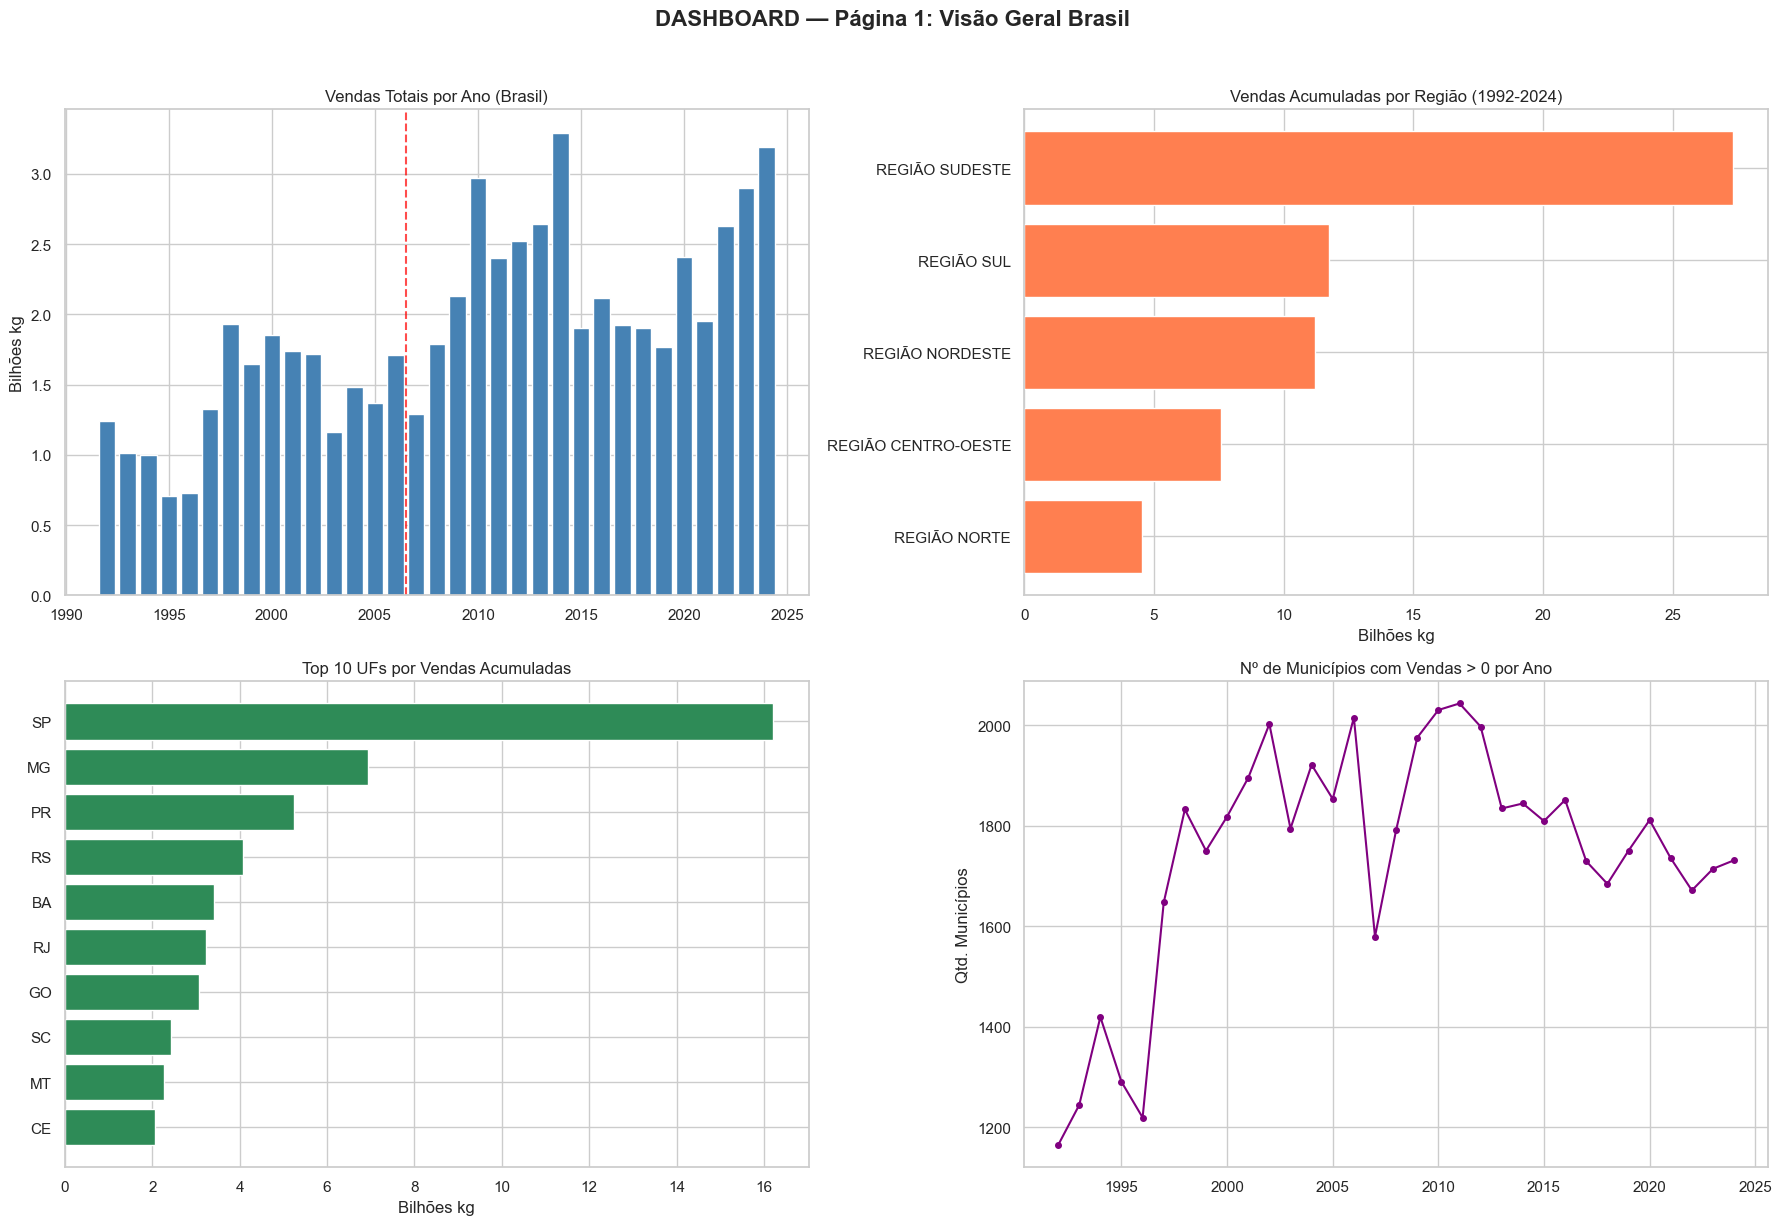

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# --- 1) Vendas totais por ano ---
axes[0, 0].bar(vendas_ano['ANO'], vendas_ano['VENDAS_KG'] / 1e9, color='steelblue')
axes[0, 0].axvline(x=2006.5, color='red', linestyle='--', alpha=0.7)
axes[0, 0].set_title('Vendas Totais por Ano (Brasil)')
axes[0, 0].set_ylabel('Bilhões kg')

# --- 2) Vendas por região (total acumulado) ---
vendas_por_regiao = df.groupby('GRANDE_REGIAO')['VENDAS_KG'].sum().sort_values(ascending=True)
axes[0, 1].barh(vendas_por_regiao.index, vendas_por_regiao.values / 1e9, color='coral')
axes[0, 1].set_title('Vendas Acumuladas por Região (1992-2024)')
axes[0, 1].set_xlabel('Bilhões kg')

# --- 3) Top 10 UFs ---
vendas_por_uf = df.groupby('UF')['VENDAS_KG'].sum().nlargest(10).sort_values(ascending=True)
axes[1, 0].barh(vendas_por_uf.index, vendas_por_uf.values / 1e9, color='seagreen')
axes[1, 0].set_title('Top 10 UFs por Vendas Acumuladas')
axes[1, 0].set_xlabel('Bilhões kg')

# --- 4) Nº de municípios com vendas por ano ---
mun_por_ano = df[df['VENDAS_KG'] > 0].groupby('ANO')['CODIGO_IBGE'].nunique().reset_index()
axes[1, 1].plot(mun_por_ano['ANO'], mun_por_ano['CODIGO_IBGE'], marker='o', color='purple', markersize=4)
axes[1, 1].set_title('Nº de Municípios com Vendas > 0 por Ano')
axes[1, 1].set_ylabel('Qtd. Municípios')

plt.suptitle('DASHBOARD — Página 1: Visão Geral Brasil', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Recorte Geográfico

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- 1) Evolução por região ---
for regiao in df['GRANDE_REGIAO'].dropna().unique():
    dados_r = df[df['GRANDE_REGIAO'] == regiao].groupby('ANO')['VENDAS_KG'].sum()
    axes[0].plot(dados_r.index, dados_r.values / 1e9, marker='.', label=str(regiao).replace('REGIÃO ', ''))

axes[0].set_title('Evolução de Vendas por Região')
axes[0].set_ylabel('Bilhões kg')
axes[0].legend(title='Região')
axes[0].axvline(x=2006.5, color='red', linestyle='--', alpha=0.5)

# --- 2) Heatmap UF x Década ---
df_temp = df.copy()
df_temp['DECADA'] = (df_temp['ANO'] // 10) * 10
heatmap_data = df_temp.groupby(['UF', 'DECADA'])['VENDAS_KG'].sum().unstack(fill_value=0) / 1e9
heatmap_data = heatmap_data.loc[heatmap_data.sum(axis=1).nlargest(15).index]
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Top 15 UFs - Vendas por Década (bilhões kg)')

plt.suptitle('DASHBOARD - Página 2: Recorte Geográfico', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.3 Série Temporal e Insights

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- 1) Série temporal + média móvel ---
axes[0].plot(vendas_ano['ANO'], vendas_ano['VENDAS_KG'] / 1e9, marker='o', markersize=4, label='Vendas')
axes[0].plot(vendas_ano['ANO'], vendas_ano['MEDIA_MOVEL_3A'] / 1e9, color='red', linewidth=2, label='Média Móvel 3A')
axes[0].axvline(x=2006.5, color='gray', linestyle='--', alpha=0.7, label='Mudança metodológica')
axes[0].set_title('Série Temporal Nacional com Média Móvel')
axes[0].set_ylabel('Bilhões kg')
axes[0].legend()

# --- 2) Variação % ano a ano ---
cores = ['green' if v >= 0 else 'red' for v in vendas_ano['VARIACAO_PCT'].fillna(0)]
axes[1].bar(vendas_ano['ANO'], vendas_ano['VARIACAO_PCT'].fillna(0), color=cores, alpha=0.8)
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_title('Variação % Ano a Ano')
axes[1].set_ylabel('Variação (%)')

plt.suptitle('DASHBOARD — Página 3: Série Temporal & Insights', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Pergunta 16 — Outliers por UF (IA/Análise)

> *"Para cada UF, analise distribuição de vendas municipais por ano (mediana, dispersão). Aplique detecção de outliers para achar municípios 'fora da curva' e quantifique quanto eles explicam do total da UF."*

### 6.1 Distribuição de Vendas por UF e Ano

In [ ]:
# Calcular estatísticas de distribuição por UF e ANO
stats_uf_ano = df.groupby(['ANO', 'UF'])['VENDAS_KG'].agg(
    ['count', 'sum', 'mean', 'median', 'std']
).reset_index()
stats_uf_ano.columns = ['ANO', 'UF', 'QTD_MUNICIPIOS', 'TOTAL_VENDAS', 'MEDIA', 'MEDIANA', 'DESVIO_PADRAO']
stats_uf_ano['COEF_VARIACAO'] = (stats_uf_ano['DESVIO_PADRAO'] / stats_uf_ano['MEDIA']).replace([np.inf, -np.inf], 0) * 100

print('=== Estatísticas de distribuição por UF/Ano (amostra) ===')
stats_uf_ano.head(15)

In [ ]:
# Mediana e dispersão (coef. variação) por UF — média ao longo dos anos
resumo_uf = stats_uf_ano.groupby('UF').agg(
    MEDIANA_MEDIA=('MEDIANA', 'mean'),
    CV_MEDIO=('COEF_VARIACAO', 'mean'),
    TOTAL_GERAL=('TOTAL_VENDAS', 'sum')
).sort_values('TOTAL_GERAL', ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mediana média por UF
top15 = resumo_uf.head(15)
axes[0].barh(top15['UF'], top15['MEDIANA_MEDIA'] / 1e3, color='steelblue')
axes[0].set_xlabel('Mediana média (mil kg)')
axes[0].set_title('Mediana Média de Vendas Municipais por UF')
axes[0].invert_yaxis()

# Coef. variação médio por UF
axes[1].barh(top15['UF'], top15['CV_MEDIO'], color='coral')
axes[1].set_xlabel('Coeficiente de Variação Médio (%)')
axes[1].set_title('Dispersão (CV%) das Vendas Municipais por UF')
axes[1].invert_yaxis()

plt.suptitle('Pergunta 16 — Distribuição por UF', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 Detecção de Outliers — Método IQR

In [ ]:
def detectar_outliers_iqr(grupo):
    """Detecta outliers usando o método IQR (1.5x) para cada grupo UF/ANO."""
    Q1 = grupo['VENDAS_KG'].quantile(0.25)
    Q3 = grupo['VENDAS_KG'].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    grupo['IS_OUTLIER'] = (grupo['VENDAS_KG'] < limite_inferior) | (grupo['VENDAS_KG'] > limite_superior)
    grupo['LIMITE_SUPERIOR'] = limite_superior
    grupo['LIMITE_INFERIOR'] = limite_inferior
    grupo['Q1'] = Q1
    grupo['Q3'] = Q3
    grupo['IQR'] = IQR
    return grupo

# Aplicar detecção de outliers por UF e ANO
df_outliers = df.groupby(['ANO', 'UF'], group_keys=False).apply(detectar_outliers_iqr)

# Resumo geral
total_registros = len(df_outliers)
total_outliers = df_outliers['IS_OUTLIER'].sum()
print(f'Total de registros: {total_registros:,}')
print(f'Total de outliers detectados: {total_outliers:,}')
print(f'Percentual de outliers: {total_outliers/total_registros*100:.1f}%')

# Amostra de outliers
print('\n=== Amostra de Outliers Detectados ===')
df_outliers[df_outliers['IS_OUTLIER']][['ANO', 'UF', 'MUNICIPIO', 'VENDAS_KG', 'LIMITE_SUPERIOR']].sort_values(
    'VENDAS_KG', ascending=False
).head(20)

### 6.3 Quantificação — Quanto os Outliers Explicam do Total da UF

In [ ]:
# Calcular impacto dos outliers por UF e ANO
impacto = df_outliers.groupby(['ANO', 'UF']).agg(
    TOTAL_UF=('VENDAS_KG', 'sum'),
    QTD_MUNICIPIOS=('VENDAS_KG', 'count'),
    QTD_OUTLIERS=('IS_OUTLIER', 'sum'),
    VENDAS_OUTLIERS=('VENDAS_KG', lambda x: x[df_outliers.loc[x.index, 'IS_OUTLIER']].sum())
).reset_index()

impacto['PCT_OUTLIERS_VENDAS'] = (impacto['VENDAS_OUTLIERS'] / impacto['TOTAL_UF'] * 100).fillna(0)
impacto['PCT_OUTLIERS_QTD'] = (impacto['QTD_OUTLIERS'] / impacto['QTD_MUNICIPIOS'] * 100).fillna(0)

print('=== Impacto dos Outliers por UF/Ano (amostra) ===')
impacto.sort_values('PCT_OUTLIERS_VENDAS', ascending=False).head(20)

In [ ]:
# Resumo geral por UF (média ao longo dos anos)
resumo_outliers_uf = impacto.groupby('UF').agg(
    MEDIA_PCT_VENDAS_OUTLIERS=('PCT_OUTLIERS_VENDAS', 'mean'),
    MEDIA_QTD_OUTLIERS=('QTD_OUTLIERS', 'mean'),
    TOTAL_VENDAS_UF=('TOTAL_UF', 'sum')
).sort_values('MEDIA_PCT_VENDAS_OUTLIERS', ascending=False).reset_index()

print('=== Resumo: % Médio das Vendas Explicado por Outliers (por UF) ===')
resumo_outliers_uf

In [ ]:
# Gráfico: % das vendas da UF explicado por outliers
fig, ax = plt.subplots(figsize=(14, 8))

dados_plot = resumo_outliers_uf.sort_values('MEDIA_PCT_VENDAS_OUTLIERS', ascending=True)
cores = ['#e74c3c' if v > 50 else '#f39c12' if v > 30 else '#2ecc71' for v in dados_plot['MEDIA_PCT_VENDAS_OUTLIERS']]

ax.barh(dados_plot['UF'], dados_plot['MEDIA_PCT_VENDAS_OUTLIERS'], color=cores)
ax.set_xlabel('% Médio das Vendas da UF Explicado por Outliers')
ax.set_title('Pergunta 16 — Concentração: Quanto os Municípios Outliers Representam por UF', fontsize=13, fontweight='bold')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='>50% (alta concentração)')
ax.axvline(x=30, color='orange', linestyle='--', alpha=0.5, label='>30% (média concentração)')
ax.legend()

# Adicionar valores nas barras
for i, (uf, v) in enumerate(zip(dados_plot['UF'], dados_plot['MEDIA_PCT_VENDAS_OUTLIERS'])):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

### 6.4 Evolução Temporal — Outliers ao Longo dos Anos

In [ ]:
# Evolução temporal do % de vendas explicado por outliers — Top 5 UFs em volume
top5_ufs = df.groupby('UF')['VENDAS_KG'].sum().nlargest(5).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

# Brasil
brasil_impacto = impacto.groupby('ANO').agg(
    VENDAS_OUTLIERS=('VENDAS_OUTLIERS', 'sum'),
    TOTAL=('TOTAL_UF', 'sum')
).reset_index()
brasil_impacto['PCT'] = brasil_impacto['VENDAS_OUTLIERS'] / brasil_impacto['TOTAL'] * 100

axes_flat[0].plot(brasil_impacto['ANO'], brasil_impacto['PCT'], marker='o', color='black', markersize=4)
axes_flat[0].set_title('BRASIL', fontweight='bold')
axes_flat[0].set_ylabel('% Vendas por Outliers')
axes_flat[0].axvline(x=2006.5, color='red', linestyle='--', alpha=0.3)

# Top 5 UFs
for idx, uf in enumerate(top5_ufs):
    dados = impacto[impacto['UF'] == uf]
    axes_flat[idx + 1].plot(dados['ANO'], dados['PCT_OUTLIERS_VENDAS'], marker='o', markersize=4, color='steelblue')
    axes_flat[idx + 1].set_title(uf, fontweight='bold')
    axes_flat[idx + 1].axvline(x=2006.5, color='red', linestyle='--', alpha=0.3)

plt.suptitle('Pergunta 16 — Evolução do % de Vendas Explicado por Outliers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.5 Quem São os Outliers? — Análise Detalhada

In [ ]:
# Municípios que mais aparecem como outlier
freq_outlier = df_outliers[df_outliers['IS_OUTLIER']].groupby(
    ['UF', 'MUNICIPIO', 'CODIGO_IBGE']
).agg(
    VEZES_OUTLIER=('IS_OUTLIER', 'sum'),
    VENDAS_TOTAL=('VENDAS_KG', 'sum'),
    VENDAS_MEDIA=('VENDAS_KG', 'mean')
).reset_index().sort_values('VEZES_OUTLIER', ascending=False)

print('=== Top 30 Municípios que Mais Aparecem como Outlier ===')
freq_outlier.head(30)

In [ ]:
# Boxplot de vendas por UF (Top 10 UFs) — visualizar outliers
dados_box = df[df['UF'].isin(top10_ufs)].copy()
dados_box['VENDAS_LOG'] = np.log10(dados_box['VENDAS_KG'].clip(lower=1))

fig, ax = plt.subplots(figsize=(16, 7))
order = df[df['UF'].isin(top10_ufs)].groupby('UF')['VENDAS_KG'].median().sort_values(ascending=False).index
sns.boxplot(data=dados_box, x='UF', y='VENDAS_LOG', order=order, ax=ax, fliersize=2)
ax.set_title('Pergunta 16 — Distribuição de Vendas Municipais por UF (escala log10)', fontsize=13, fontweight='bold')
ax.set_ylabel('log10(Vendas em kg)')
ax.set_xlabel('UF')
plt.tight_layout()
plt.show()

In [ ]:
# Análise final: para cada UF, listar os top 3 outliers mais frequentes e seu impacto
print('=' * 90)
print('RESUMO FINAL — Pergunta 16: Outliers por UF')
print('=' * 90)

for uf in resumo_outliers_uf.sort_values('TOTAL_VENDAS_UF', ascending=False)['UF'].head(10):
    dados_uf = resumo_outliers_uf[resumo_outliers_uf['UF'] == uf].iloc[0]
    top_outliers_uf = freq_outlier[freq_outlier['UF'] == uf].head(3)
    
    print(f'\n📍 {uf}')
    print(f'   % médio das vendas explicado por outliers: {dados_uf["MEDIA_PCT_VENDAS_OUTLIERS"]:.1f}%')
    print(f'   Média de municípios outlier por ano: {dados_uf["MEDIA_QTD_OUTLIERS"]:.1f}')
    print(f'   Top outliers:')
    for _, row in top_outliers_uf.iterrows():
        print(f'     - {row["MUNICIPIO"]} ({row["VEZES_OUTLIER"]}x outlier, total: {row["VENDAS_TOTAL"]/1e6:.1f}M kg)')

print('\n' + '=' * 90)

---
## 7. Conclusões — Pergunta 16

### Principais achados:

1. **Alta concentração em poucos municípios**: Na maioria das UFs, um pequeno grupo de municípios (geralmente capitais e polos industriais) é classificado como outlier e responde por uma parcela significativa das vendas totais do estado.

2. **Capitais dominam**: Municípios como São Paulo, Rio de Janeiro, Belo Horizonte, Salvador e Goiânia aparecem consistentemente como outliers ao longo de todo o período, demonstrando concentração estrutural.

3. **Dispersão varia por UF**: UFs com maior diversidade econômica (ex: SP, MG) tendem a ter mais municípios com vendas relevantes, resultando em menor concentração relativa nos outliers. UFs menores podem ter 1-2 municípios dominando completamente.

4. **Padrão estável no tempo**: A concentração em outliers mantém-se relativamente estável ao longo dos anos, indicando que a estrutura de distribuição de asfalto segue padrões geográficos e logísticos consolidados.

5. **Mudança metodológica (2007)**: A quebra de série em 2007 afeta os volumes absolutos mas não altera significativamente o padrão de concentração/outliers dentro de cada UF.

### Método utilizado:
- **IQR (Interquartil Range)**: Q1 - 1.5×IQR a Q3 + 1.5×IQR
- Aplicado por **UF × ANO** para capturar variações regionais e temporais
- Quantificação: % das vendas da UF explicado pelos municípios outlier